## MODELO PREDICCIÓN: LSTM
CESNET TIME SERIES 24 - AGGREGATION 10 MINUTE


In [1]:
# IMPORTS, FUNCIONES Y DIRECTORIOS

# IMPORTS
import pandas as pd
import numpy as np
import os
import tqdm
from scipy.io import savemat
import matplotlib.pyplot as plt
import ast  # Para convertir strings que representan listas a listas reales
import warnings
warnings.filterwarnings("ignore")
import skfda
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.ml.clustering import KMeans
from datetime import datetime
from datetime import date
from skfda.representation.basis import BSplineBasis, FourierBasis
from skfda.misc.metrics import lp_distance
from skfda.representation.grid import FDataGrid
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from sklearn.metrics import silhouette_score
from skfda.misc.metrics import LpDistance
import torch 
import torch.nn as nn 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler 
from itertools import product
import pywt

# FUNCIONES
# Ajustar el eje X para mostrar fechas en lugar de segundos Unix
# a) Convertir los valores del eje x (segundos Unix) a un formato numérico
# que Matplotlib pueda interpretar como fecha (días desde el año 0)
# Esto se hace usando la función personalizada UnixConverter.
# Como FDataGrid usa los segundos directamente, la conversión
# debe hacerse en el formateador o usar una aproximación.

# En Matplotlib, `ax.xaxis.set_major_formatter()` es lo que necesitas.
# Usaremos un formateador que convierta los segundos Unix a objetos datetime.
def unix_to_date_formatter(unix_timestamp, pos):
    """
    Formateador de Matplotlib para convertir segundos Unix a fecha.
    """
    # Se añade un pequeño offset si Matplotlib lo requiere, pero generalmente
    # epoch2num es el conversor más limpio para Matplotlib.
    return pd.to_datetime(unix_timestamp, unit='s').strftime('%Y-%m-%d')
    # O para una representación de solo día/mes:
    # return pd.to_datetime(unix_timestamp, unit='s').strftime('%d %b')


def aplicar_mu_law(df, mu=255, col_time="time"):
    def transformar_columna(x):
        x_max = x.abs().max()
        if x_max == 0:
            return x

        x_norm = x / x_max
        x_mu = np.sign(x_norm) * (np.log(1 + mu * np.abs(x_norm)) / np.log(1 + mu))
        return x_mu

    # Separar time
    time = df[col_time]
    data = df.drop(columns=[col_time])

    # Aplicar Mu-Law solo a las señales
    data_mu = data.apply(transformar_columna)

    # Volver a unir time
    data_mu[col_time] = time

    return data_mu


def t_to_datetime_info(t_norm):
    """
    Convierte t ∈ [0,1] a día, hora y minuto reales
    """
    minutes_per_week = 7 * 24 * 60

    total_minutes = t_norm * minutes_per_week

    day_idx = int(total_minutes // (24 * 60))
    day_idx = min(day_idx, 6)  # seguridad numérica

    minutes_in_day = total_minutes % (24 * 60)
    hour = int(minutes_in_day // 60)
    minute = int(minutes_in_day % 60)

    days = ["Lunes", "Martes", "Miércoles",
            "Jueves", "Viernes", "Sábado", "Domingo"]

    return days[day_idx], hour, minute


def t_to_original_index(t_norm, n_points=1008):
    """
    Mapea t ∈ [0,1] al índice original más cercano
    """
    idx = int(round(t_norm * (n_points - 1)))
    return max(0, min(idx, n_points - 1))


def parse_week_column(col_name):
    """
    Ejemplo: 'n_flows_0_41_2023'
    → variable='n_flows_0', week=41, year=2023
    """
    parts = col_name.split("_")
    year = int(parts[-1])
    week = int(parts[-2])
    variable = "_".join(parts[:-2])
    return variable, week, year

def get_week_mask(df_ts, week, year):
    return (
        (df_ts.index.isocalendar().week == week) &
        (df_ts.index.isocalendar().year == year)
    )

def compute_optimal_window(signal, wavelet='db4', max_level=6):
    coeffs = pywt.wavedec(signal, wavelet, level=max_level)

    # coeffs = [A_j, D_j, D_{j-1}, ..., D1]
    energies = []

    for i in range(1, len(coeffs)):  # solo detalles
        Dj = coeffs[i]
        energy = np.sum(Dj**2)
        energies.append(energy)

    energies = np.array(energies)

    # Normalizar energías
    energies_norm = energies / np.sum(energies)

    # Buscar el "corte": donde la energía deja de ser relevante
    threshold = np.mean(energies_norm)
    significant_levels = np.where(energies_norm > threshold)[0]

    if len(significant_levels) == 0:
        j_opt = 1
    else:
        j_opt = significant_levels[-1] + 1  # +1 porque empezamos en D1

    window_size = 2 ** j_opt

    return window_size, energies_norm


# DIRECTORIOS
DATASET_PATH = r"C:\Users\itsal\Desktop\MASTER\TFM\CESNET\CESNET_TimeSeries24"

IP_ADDRESSES_SAMPLE = os.path.join(DATASET_PATH, "ip_addresses_sample")
INSTITUTIONS = os.path.join(DATASET_PATH, "institutions")
INSTITUTION_SUBNETS = os.path.join(DATASET_PATH, "institution_subnets")
##IP_ADDRESSES_FULL = os.path.join(DATASET_PATH, "ip_addresses_full")


TIMES_10_MINUTES = os.path.join(DATASET_PATH, "times", "times_10_minutes.csv")
TIMES_1_HOUR = os.path.join(DATASET_PATH, "times", "times_1_hour.csv")
TIMES_1_DAY = os.path.join(DATASET_PATH, "times", "times_1_day.csv")


# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar
agg_1_day_path = os.path.join(INSTITUTIONS, "agg_1_day")
agg_1_hour_path = os.path.join(INSTITUTIONS, "agg_1_hour")
agg_10_minutes_path = os.path.join(INSTITUTIONS, "agg_10_minutes")
agg_10_minutes_filtrado_path = os.path.join(INSTITUTIONS, "agg_10_minutes_filtrado")
# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar

In [2]:
# VARIABLES PARA USAR
file_path = os.path.join(agg_10_minutes_filtrado_path, os.listdir(agg_10_minutes_filtrado_path)[0])
df_TS24 = pd.read_csv(file_path)
print(df_TS24.columns[1:].tolist())


['n_flows', 'n_packets', 'n_bytes', 'sum_n_dest_asn', 'average_n_dest_asn', 'std_n_dest_asn', 'sum_n_dest_ports', 'average_n_dest_ports', 'std_n_dest_ports', 'sum_n_dest_ip', 'average_n_dest_ip', 'std_n_dest_ip', 'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes', 'avg_duration', 'avg_ttl']


In [3]:
# ELECCIÓN DE VARIABLE
variable = "n_packets"

In [4]:
# INSTITUCIONES DISPONIBLES
# Leer mapping id_time → time
times_df = pd.read_csv(TIMES_10_MINUTES)

# Lista para ir acumulando los dataframes procesados
dfs_companded = []

# Recorrer todos los CSV de la carpeta
for file in sorted(os.listdir(agg_10_minutes_filtrado_path)):
    if file.endswith(".csv"):
        
        fpath = os.path.join(agg_10_minutes_filtrado_path, file)
        
        # Leer CSV
        df = pd.read_csv(fpath)
        
        # Comprobar que la variable existe
        if variable not in df.columns:
            raise ValueError(f"La variable '{variable}' no existe en {file}")
        
        # Merge para sustituir id_time por time
        df = (
            df.merge(times_df, on="id_time", how="left")
              .drop(columns=["id_time"])
        )
        
        # Renombrar la columna como variable_institucion
        institucion = file.replace(".csv", "")
        new_col = f"{variable}_{institucion}"
        
        df = df[["time", variable]].rename(columns={variable: new_col})
        
        # Convertir time a datetime y eliminar zona horaria
        df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
        
        # COMPANDING
        df_companded = aplicar_mu_law(df)
        
        # Reordenar columnas (time primero)
        cols = ['time'] + [c for c in df_companded.columns if c != 'time']
        df_companded = df_companded[cols]
        
        dfs_companded.append(df_companded)

# Unir todos por la columna 'time'
from functools import reduce

df_TS24_companded = reduce(
    lambda left, right: pd.merge(left, right, on="time", how="outer"),
    dfs_companded
)

# Ordenar por tiempo
df_TS24_companded = df_TS24_companded.sort_values("time").reset_index(drop=True)

df_TS24_companded


,time,n_packets_0,n_packets_10,n_packets_108,n_packets_109,n_packets_113,n_packets_139,n_packets_145,n_packets_147,n_packets_161,...,n_packets_56,n_packets_57,n_packets_59,n_packets_62,n_packets_68,n_packets_69,n_packets_70,n_packets_80,n_packets_86,n_packets_93
0,2023-10-09 00:03:49,0.556011,0.308059,0.320938,0.436240,0.483470,0.028138,0.053862,0.011124,0.046420,...,0.350974,0.300686,0.289392,0.012802,0.365583,0.375635,0.032108,0.366409,0.143416,0.046948
1,2023-10-09 00:13:49,0.612719,0.139530,0.331892,0.353694,0.419183,0.209788,0.039296,0.031258,0.046985,...,0.266701,0.276901,0.305307,0.011221,0.513558,0.226597,0.049837,0.349239,0.175270,0.053418
2,2023-10-09 00:23:49,0.529257,0.164183,0.331369,0.408780,0.598810,0.028003,0.043695,0.013011,0.054506,...,0.321299,0.271488,0.295524,0.015232,0.286149,0.290228,0.019230,0.245545,0.112729,0.042443
3,2023-10-09 00:33:49,0.545362,0.095732,0.291178,0.405769,0.500413,0.026490,0.052158,0.011774,0.086026,...,0.295125,0.329172,0.298182,0.011511,0.315418,0.139137,0.046266,0.345947,0.180590,0.049438
4,2023-10-09 00:43:49,0.550940,0.127565,0.433107,0.421811,0.557780,NaN,0.116546,0.032312,0.106470,...,0.222086,0.331067,0.326017,0.012131,0.389620,0.179745,0.037714,0.413748,0.264052,0.054488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40293,2024-07-14 21:10:52,0.665485,0.200044,0.461846,0.400540,0.380357,0.008315,0.119590,0.009036,0.089353,...,0.194255,0.343790,0.414215,0.024924,0.514114,0.248525,0.010433,0.494226,0.124322,0.039821
40294,2024-07-14 21:20:52,0.689312,0.164220,0.499865,0.396086,0.399295,0.006449,0.104549,0.007381,0.068348,...,0.279120,0.362446,0.317204,0.028088,0.377748,0.216633,0.117986,0.417027,0.364026,0.159904
40295,2024-07-14 21:30:52,0.732208,0.234784,0.442110,0.409848,0.444484,NaN,0.129387,0.005440,0.071905,...,0.252054,0.366446,0.393873,0.027207,0.341581,0.152202,0.005644,0.635731,0.158493,0.036476
40296,2024-07-14 21:40:52,0.653425,0.206730,0.514592,0.384495,0.435723,NaN,0.111082,0.008739,0.080957,...,0.225311,0.312003,0.350342,0.025688,0.335605,0.222211,0.004297,0.473662,0.272068,0.135214


SEMANAS TOTALES: 32 

Comienza desde Semana 49, 2023 = lunes, 4 de diciembre ---> domingo, 10 de diciembre de 2023

Debido al comportamiento anomalo del principio del dataset. 

In [5]:
# DF CON TODAS LAS SEMANAS DE TODOS LOS FICHEROS
# -----------------------------------
# SEPARAR DF EN SEMANAS (una vez)
# -----------------------------------

iso = df_TS24_companded['time'].dt.isocalendar()
df_TS24_companded['iso_year'] = iso.year
df_TS24_companded['iso_week'] = iso.week

# Columnas reales (excluyendo auxiliares)
data_columns = [
    c for c in df_TS24_companded.columns 
    if c not in ['time', 'iso_year', 'iso_week']
]

weekly_data = {}

# -----------------------------------
# PROCESAR TODAS LAS COLUMNAS
# -----------------------------------

for variable_col in data_columns:

    for (year, week), group in df_TS24_companded.groupby(['iso_year', 'iso_week']):
        
        col_name = f"{variable_col}_{int(week):02d}_{int(year)}"
        weekly_data[col_name] = group[variable_col].reset_index(drop=True)

# Crear único DataFrame final
df_weeks = pd.DataFrame(weekly_data)




import re

def keep_column(col):
    # Busca patrón: _<semana>_<año> al final
    match = re.search(r'_(\d{1,2})_(\d{4})$', col)
    if match:
        week = int(match.group(1))
        year = int(match.group(2))
        
        # Mantener solo si es >= semana 49 de 2023
        return (year > 2023) or (year == 2023 and week >= 49)
    
    # Si la columna no tiene fecha, la dejamos
    return True

df_weeks = df_weeks[[col for col in df_weeks.columns if keep_column(col)]]

df_weeks

,n_packets_0_49_2023,n_packets_0_50_2023,n_packets_0_51_2023,n_packets_0_52_2023,n_packets_0_01_2024,n_packets_0_02_2024,n_packets_0_03_2024,n_packets_0_04_2024,n_packets_0_05_2024,n_packets_0_06_2024,...,n_packets_93_19_2024,n_packets_93_20_2024,n_packets_93_21_2024,n_packets_93_22_2024,n_packets_93_23_2024,n_packets_93_24_2024,n_packets_93_25_2024,n_packets_93_26_2024,n_packets_93_27_2024,n_packets_93_28_2024
0,0.723969,0.725587,0.702604,0.629336,0.599773,0.595336,0.554228,0.530591,0.691167,0.633386,...,0.037337,0.054758,0.037113,0.019459,0.018985,0.033479,0.036993,0.031225,0.032347,0.025493
1,0.668322,0.695635,0.659520,0.694687,0.638043,0.592817,0.625738,0.459894,0.667583,0.649483,...,0.029590,0.069814,0.026614,0.022038,0.024402,0.066656,0.023971,0.034998,0.193903,0.023434
2,0.660500,0.689444,0.620074,0.583893,0.646308,0.602545,0.636503,0.497940,0.642675,0.613608,...,0.037451,0.057537,0.111421,0.022393,0.026887,0.031799,0.026487,0.040024,0.089308,0.023020
3,0.668982,0.685812,0.643900,0.542177,0.625789,0.584312,0.601348,0.527492,0.751679,0.605859,...,0.044825,0.040091,0.022604,0.027323,0.015969,0.075987,0.027021,0.038250,0.023255,0.019086
4,0.669047,0.715490,0.604988,0.610449,0.622142,0.571461,0.585818,0.444755,0.634255,0.620129,...,0.036735,0.044204,0.032411,0.026207,0.020222,0.030025,0.021070,0.037234,0.033747,0.022920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,0.752083,0.769259,0.693026,0.634121,0.717784,0.694909,0.637606,0.758113,0.739107,0.659039,...,0.059729,0.032117,0.017074,0.022865,0.028168,0.021976,0.031450,0.035704,0.026936,NaN
1004,0.781181,0.766703,0.648280,0.602286,0.688963,0.626773,0.588929,0.696254,0.726003,0.616601,...,0.053951,0.022399,0.013922,0.025040,0.030049,0.025536,0.040991,0.033992,0.037085,NaN
1005,0.732735,0.736264,0.669987,0.610378,0.632965,0.619601,0.505011,0.704002,0.743235,0.617732,...,0.051888,0.029900,0.019945,0.021895,0.026845,0.028595,0.036119,0.035687,0.022920,NaN
1006,0.718102,0.692986,0.676527,0.666777,0.598466,0.635378,0.556107,0.679608,0.689005,0.651049,...,0.046633,0.023403,0.021851,0.022050,0.031048,0.037720,0.046448,0.273371,0.027595,NaN


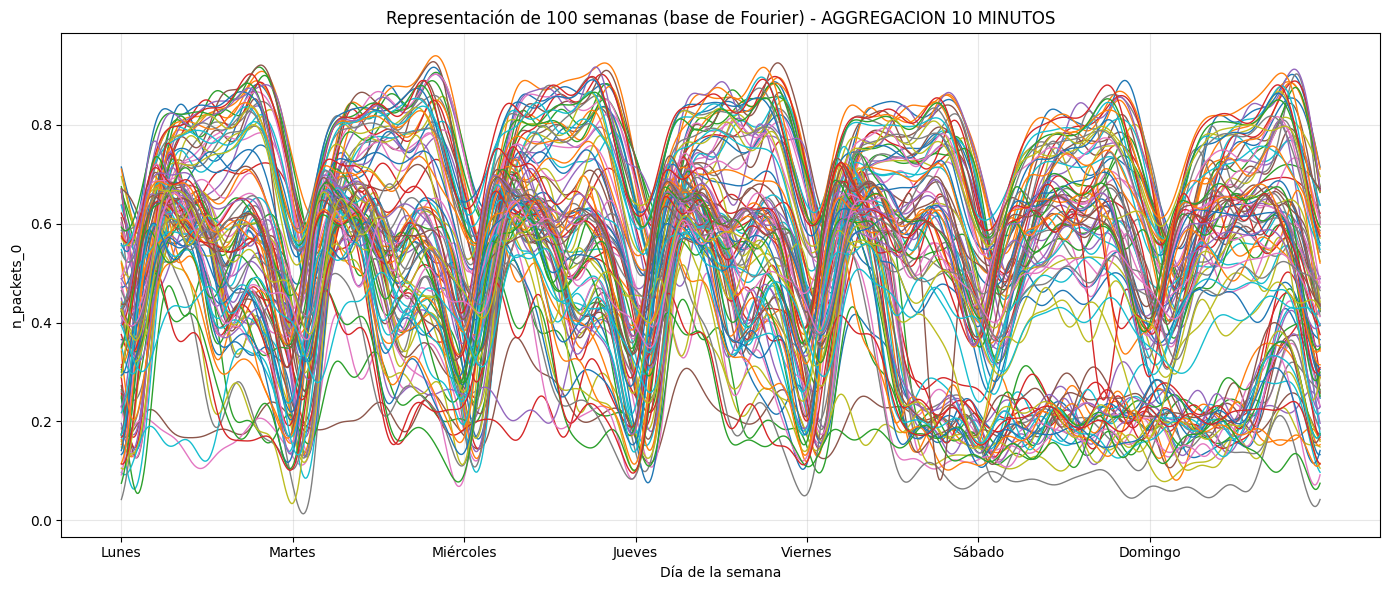

In [6]:
# PASAR DE DATOS ESCALARES A DATOS FUNCIONALES + REPRESENTACION
# ==========================================================
# 1️⃣ LIMPIEZA ROBUSTA
# ==========================================================

df_weeks_clean = df_weeks.copy()

# Convertir ±inf en NaN
df_weeks_clean = df_weeks_clean.replace([np.inf, -np.inf], np.nan)

# Eliminar columnas completamente vacías
df_weeks_clean = df_weeks_clean.dropna(axis=1, how="all")

# Interpolación temporal (por columnas = semanas)
df_weeks_clean = df_weeks_clean.interpolate(
    axis=0,
    method="linear",
    limit_direction="both"
)

# Relleno de seguridad
df_weeks_clean = df_weeks_clean.ffill().bfill()


# ==========================================================
# 2️⃣ DEFINIR DOMINIO TEMPORAL
# ==========================================================

n_time = df_weeks_clean.shape[0]  # puntos temporales por semana

t = np.linspace(0, 1, n_time)  # dominio normalizado [0,1]

# ==========================================================
# 3️⃣ CREAR OBJETO FUNCIONAL
# ==========================================================

fd = FDataGrid(
    data_matrix=df_weeks_clean.T.values,  # (n_semanas, n_time)
    grid_points=t
)

# ==========================================================
# 4️⃣ PROYECCIÓN A BASE DE FOURIER
# ==========================================================

n_basis = 60  # puedes ajustar

basis = FourierBasis(
    domain_range=(0, 1),
    n_basis=n_basis
)

fd_fourier = fd.to_basis(basis)

# ==========================================================
# 5️⃣ EVALUAR FUNCIONES EN LA REJILLA
# ==========================================================

X = fd_fourier(t)  # evaluación
X = X.reshape(X.shape[0], -1)  # aseguramos shape (n_semanas, n_time)

# Convertir a DataFrame con índice correcto
X = pd.DataFrame(
    X,
    index=df_weeks_clean.columns,   # nombres de semanas
    columns=[f"t_{i}" for i in range(X.shape[1])]
)
# ==========================================================
# 6️⃣ REPRESENTACIÓN DE FUNCIONES (≥ 100)
# ==========================================================

# Número de funciones a representar
n_plot = min(100, X.shape[0])

# Eje temporal en horas (10 minutos por punto)
minutes_per_step = 10
x_hours = np.arange(n_time) * minutes_per_step / 60  # 0 → 168 horas

# Ticks diarios
days = ["Lunes", "Martes", "Miércoles", "Jueves",
        "Viernes", "Sábado", "Domingo"]
ticks = np.arange(0, 7 * 24, 24)

plt.figure(figsize=(14, 6))

for idx in X.index[:n_plot]:
    plt.plot(
        x_hours,
        X.loc[idx],
        linewidth=1
    )

plt.title(f"Representación de {n_plot} semanas (base de Fourier) - AGGREGACION 10 MINUTOS")
plt.xlabel("Día de la semana")
plt.ylabel(df_TS24_companded.columns[1])
plt.xticks(ticks, days)
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Guardar en PDF
plt.savefig(
    "rep_func_10MIN.pdf",
    format="pdf",
    bbox_inches="tight"
)


plt.show()



In [7]:
# DATAFRAME CON LOS COEF. DE LA BASE DE FOURIER
n_coef = fd_fourier.coefficients.shape[1]

coef_df = pd.DataFrame(
    fd_fourier.coefficients,
    index=df_weeks_clean.columns,
    columns=[f"coef_{i}" for i in range(n_coef)]
)

coef_df

,coef_0,coef_1,coef_2,coef_3,coef_4,coef_5,coef_6,coef_7,coef_8,coef_9,...,coef_51,coef_52,coef_53,coef_54,coef_55,coef_56,coef_57,coef_58,coef_59,coef_60
n_packets_0_49_2023,0.772250,0.008644,-0.009684,-0.006623,0.000545,-0.005755,0.011793,0.006268,0.002927,0.001313,...,-0.004038,-0.001824,-0.004479,0.000091,0.004604,-0.000052,0.002454,-0.002142,0.002528,-0.000355
n_packets_0_50_2023,0.783237,0.027851,-0.014708,-0.000467,-0.001933,0.002306,0.002992,0.001991,0.000269,0.001445,...,0.000522,0.001154,-0.000308,0.001437,0.004028,0.000417,-0.000336,0.001532,-0.001590,-0.000922
n_packets_0_51_2023,0.722674,0.058982,-0.021153,0.020784,0.008861,0.008845,-0.003415,0.013143,0.001090,0.015090,...,-0.002016,-0.001705,0.000246,0.006993,0.006115,0.001107,0.001544,-0.001849,0.000859,0.001252
n_packets_0_52_2023,0.624339,-0.002532,0.007238,0.005979,-0.006303,0.003203,-0.007215,0.002725,0.002777,0.002178,...,0.002659,-0.000437,-0.002251,0.001934,0.004191,0.000474,-0.000530,0.000087,0.002311,-0.001468
n_packets_0_01_2024,0.662837,0.012644,-0.012012,0.001644,-0.000910,-0.006820,0.001208,0.001303,-0.000865,-0.006809,...,-0.001814,-0.001523,-0.003391,-0.000262,0.006924,0.000515,-0.000269,-0.002578,0.001143,-0.000873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
n_packets_93_24_2024,0.179536,0.058591,-0.020578,0.029994,0.021081,-0.003821,-0.002421,0.009120,0.009814,0.025344,...,-0.002916,-0.001530,-0.008345,-0.011072,-0.018441,0.010585,0.001507,0.011374,0.000502,-0.001512
n_packets_93_25_2024,0.166931,0.031292,-0.004987,0.035477,0.006529,0.024596,-0.012358,0.005107,0.028372,0.012233,...,-0.002122,-0.004395,-0.002599,-0.000757,-0.018929,0.005076,0.000698,0.002436,0.003739,0.008976
n_packets_93_26_2024,0.145807,0.068224,0.024140,0.037121,0.002637,0.008767,-0.003061,0.008192,0.009907,0.018731,...,-0.001585,-0.004465,-0.002052,-0.011966,-0.020462,0.007373,0.000541,0.003590,-0.005545,0.002020
n_packets_93_27_2024,0.054848,0.004343,0.003269,0.001853,-0.000225,0.001716,0.001035,0.003520,0.001008,0.003364,...,0.000027,-0.000741,-0.000331,-0.001864,0.000075,0.000858,-0.002414,0.002944,0.000798,0.002420


In [8]:
# DATAFRAME CON LA SERIE TEMPORAL RECONSTRUIDA
X

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_998,t_999,t_1000,t_1001,t_1002,t_1003,t_1004,t_1005,t_1006,t_1007
n_packets_0_49_2023,0.714443,0.703836,0.693514,0.683516,0.673879,0.664636,0.655821,0.647470,0.639618,0.632302,...,0.814627,0.803806,0.792745,0.781519,0.770201,0.758859,0.747555,0.736350,0.725297,0.714443
n_packets_0_50_2023,0.710409,0.698423,0.686475,0.674651,0.663039,0.651731,0.640817,0.630389,0.620539,0.611353,...,0.808514,0.799136,0.789281,0.778981,0.768272,0.757200,0.745817,0.734180,0.722354,0.710409
n_packets_0_51_2023,0.662990,0.656938,0.650553,0.643889,0.637011,0.629999,0.622942,0.615942,0.609108,0.602558,...,0.699736,0.697130,0.694210,0.690943,0.687302,0.683265,0.678817,0.673951,0.668670,0.662990
n_packets_0_52_2023,0.621189,0.615243,0.608949,0.602315,0.595354,0.588088,0.580548,0.572772,0.564812,0.556723,...,0.660673,0.657332,0.653774,0.649980,0.645930,0.641605,0.636985,0.632051,0.626790,0.621189
n_packets_0_01_2024,0.637874,0.629666,0.621578,0.613607,0.605750,0.597998,0.590341,0.582769,0.575271,0.567841,...,0.714019,0.705792,0.697390,0.688873,0.680293,0.671698,0.663130,0.654620,0.646195,0.637874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
n_packets_93_24_2024,0.004256,0.001605,0.000377,0.000798,0.003075,0.007392,0.013903,0.022727,0.033944,0.047590,...,0.054488,0.048978,0.043070,0.036890,0.030593,0.024356,0.018380,0.012883,0.008096,0.004256
n_packets_93_25_2024,0.016899,0.014677,0.013338,0.013093,0.014147,0.016700,0.020935,0.027013,0.035071,0.045211,...,0.047033,0.044378,0.041347,0.037990,0.034381,0.030621,0.026835,0.023170,0.019796,0.016899
n_packets_93_26_2024,0.033165,0.029004,0.026186,0.025009,0.025745,0.028639,0.033897,0.041683,0.052111,0.065241,...,0.082255,0.078818,0.074417,0.069195,0.063334,0.057055,0.050611,0.044281,0.038362,0.033165
n_packets_93_27_2024,0.049461,0.050560,0.051486,0.052259,0.052904,0.053453,0.053946,0.054423,0.054928,0.055505,...,0.032920,0.035027,0.037161,0.039274,0.041322,0.043264,0.045069,0.046713,0.048180,0.049461


FORECASTING DE VARIABLES




Cálculo de deltas

In [9]:
# =========================================
# CONFIG
# =========================================

START_WEEK = (2024, 19)
TARGET_INST = 0

WINDOW_SIZE = 12
EPOCHS = 400
patience = 40

# =========================================
# IMPORTS
# =========================================

import numpy as np
import pandas as pd
import re
import torch
import torch.nn as nn
import random

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# =========================================
# PARSE INDEX
# =========================================

def parse_index(idx):
    match = re.match(r"n_packets_(\d+)_(\d+)_(\d+)", idx)
    inst, week, year = match.groups()
    return int(inst), int(year), int(week)

df = coef_df.copy()

df[['inst','year','week']] = df.index.to_series().apply(
    lambda x: pd.Series(parse_index(x))
)

df = df.sort_values(['inst','year','week'])

coef_cols = coef_df.columns

# =========================================
# SPLIT
# =========================================

def split_data(df, train_end, test_week):
    y_end, w_end = train_end
    y_test, w_test = test_week
    
    train = df[
        (df['year'] < y_end) |
        ((df['year'] == y_end) & (df['week'] <= w_end))
    ]
    
    test = df[
        (df['year'] == y_test) &
        (df['week'] == w_test)
    ]
    
    return train, test

# =========================================
# SECUENCIAS
# =========================================

def create_sequences(df):
    X, y, inst_ids = [], [], []
    scalers = {}
    
    inst_list = sorted(df['inst'].unique())
    inst_to_idx = {inst:i for i,inst in enumerate(inst_list)}
    
    for inst in inst_list:
        df_inst = df[df['inst'] == inst].sort_values(['year','week'])
        values = df_inst[coef_cols].values
        
        if len(values) < WINDOW_SIZE + 1:
            continue
        
        values_no_dc = values[:, 1:]
        deltas = np.diff(values_no_dc, axis=0)
        
        scaler = StandardScaler()
        deltas_scaled = scaler.fit_transform(deltas)
        
        scalers[inst] = scaler
        
        for i in range(len(deltas_scaled) - WINDOW_SIZE):
            X.append(deltas_scaled[i:i+WINDOW_SIZE])
            y.append(deltas_scaled[i+WINDOW_SIZE])
            inst_ids.append(inst_to_idx[inst])
    
    return np.array(X), np.array(y), np.array(inst_ids), inst_to_idx, scalers

# =========================================
# MODELO
# =========================================

best_params = {
    'hidden_size': 256,
    'num_layers': 1,
    'dropout': 0.0,
    'lr': 0.0005,
    'embedding_dim': 8
}

class LSTMModel(nn.Module):
    def __init__(self, input_size, num_insts):
        super().__init__()
        
        self.embedding = nn.Embedding(num_insts, best_params['embedding_dim'])
        
        self.lstm = nn.LSTM(
            input_size + best_params['embedding_dim'],
            best_params['hidden_size'],
            num_layers=best_params['num_layers'],
            dropout=best_params['dropout'],
            batch_first=True
        )
        
        self.fc = nn.Linear(best_params['hidden_size'], input_size)

    def forward(self, x, inst_id):
        emb = self.embedding(inst_id)
        emb = emb.unsqueeze(1).repeat(1, x.size(1), 1)
        x = torch.cat([x, emb], dim=2)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# =========================================
# RECONSTRUCCIÓN
# =========================================

def reconstruct_signal_week(coefs, n_points):
    t = np.linspace(0, 2*np.pi, n_points)
    result = np.ones_like(t) * coefs[0]
    k = 1
    idx = 1
    while idx < len(coefs)-1:
        result += coefs[idx]*np.cos(k*t) + coefs[idx+1]*np.sin(k*t)
        idx += 2
        k += 1
    return result

# =========================================
# WALK-FORWARD VALIDATION
# =========================================

results_list = []

weeks_df = df[['year','week']].drop_duplicates().sort_values(['year','week'])
weeks = list(weeks_df.itertuples(index=False, name=None))

start_idx = weeks.index(START_WEEK)

n_time = int(7 * 24 * 60 / 10)

for i in range(start_idx, len(weeks)):
    
    TEST_WEEK = weeks[i]
    TRAIN_END = weeks[i-1]
    
    train_df, test_df = split_data(df, TRAIN_END, TEST_WEEK)
    
    if len(test_df[test_df['inst'] == TARGET_INST]) == 0:
        continue
    
    # =========================
    # SECUENCIAS
    # =========================
    X, y, inst_ids, inst_to_idx, scalers = create_sequences(train_df)
    
    if len(X) == 0:
        continue

    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)
    inst_ids = torch.tensor(inst_ids, dtype=torch.long)

    X_train, X_val, y_train, y_val, inst_train, inst_val = train_test_split(
        X, y, inst_ids, test_size=0.2, random_state=42
    )
    
    # =========================
    # MODELO
    # =========================
    model = LSTMModel(X.shape[2], len(inst_to_idx))
    optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'])
    criterion = nn.SmoothL1Loss()
    
    best_loss = float('inf')
    counter = 0

    for epoch in range(EPOCHS):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train, inst_train), y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val, inst_val), y_val)

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
        else:
            counter += 1

        if counter > patience:
            break

    # =========================
    # PREDICCIÓN
    # =========================
    if TARGET_INST not in inst_to_idx:
        continue

    inst_idx = inst_to_idx[TARGET_INST]

    df_inst = train_df[train_df['inst'] == TARGET_INST].sort_values(['year','week'])
    values = df_inst[coef_cols].values

    if len(values) < WINDOW_SIZE + 1:
        continue

    baseline = values[:, 0]
    shape = values[:, 1:]

    deltas = np.diff(shape, axis=0)
    scaler = scalers[TARGET_INST]
    deltas_scaled = scaler.transform(deltas)

    last_window = torch.tensor(deltas_scaled[-WINDOW_SIZE:], dtype=torch.float32).unsqueeze(0)
    inst_tensor = torch.tensor([inst_idx])

    with torch.no_grad():
        pred_delta = scaler.inverse_transform(
            model(last_window, inst_tensor).numpy()
        )[0]

    pred_shape = shape[-1] + pred_delta
    pred_coef = np.concatenate([[baseline[-1]], pred_shape])

    real = test_df[test_df['inst'] == TARGET_INST][coef_cols].values[0]

    # =========================
    # MÉTRICAS
    # =========================
    signal_real = reconstruct_signal_week(real, n_time)
    signal_pred = reconstruct_signal_week(pred_coef, n_time)

    mae = np.mean(np.abs(signal_real - signal_pred))
    rmse = np.sqrt(np.mean((signal_real - signal_pred)**2))

    results_list.append({
        'year': TEST_WEEK[0],
        'week': TEST_WEEK[1],
        'mae': mae,
        'rmse': rmse
    })

# =========================================
# RESULTADO FINAL
# =========================================

results_df = pd.DataFrame(results_list).sort_values(['year','week']).reset_index(drop=True)

results_df

,year,week,mae,rmse
0,2024,19,0.030792,0.040237
1,2024,20,0.020148,0.025186
2,2024,21,0.138439,0.153122
3,2024,22,0.084131,0.101999
4,2024,23,0.065256,0.070075
5,2024,24,0.048993,0.061076
6,2024,25,0.028201,0.036783
7,2024,26,0.045694,0.056137
8,2024,27,0.066862,0.073202
9,2024,28,0.036512,0.045399


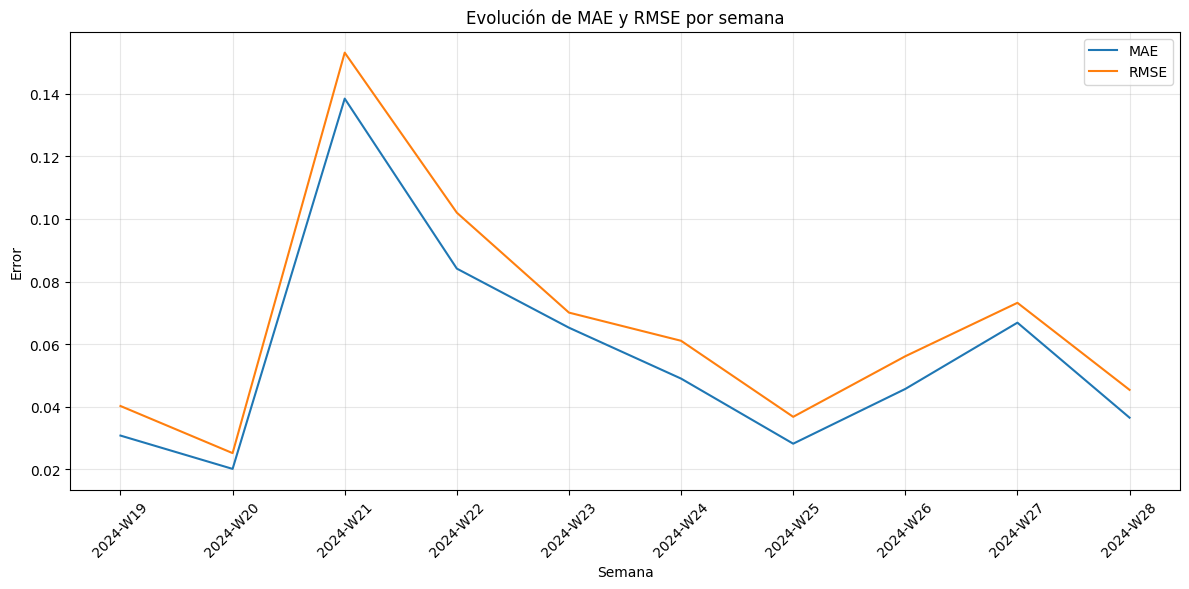

In [10]:
import matplotlib.pyplot as plt

# Crear etiqueta de semana tipo "2024-W19"
results_df['year_week'] = results_df['year'].astype(str) + '-W' + results_df['week'].astype(str)

plt.figure(figsize=(12,6))

plt.plot(results_df['year_week'], results_df['mae'], label='MAE')
plt.plot(results_df['year_week'], results_df['rmse'], label='RMSE')

plt.xticks(rotation=45)
plt.xlabel('Semana')
plt.ylabel('Error')
plt.title('Evolución de MAE y RMSE por semana')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Guardar en PDF
#plt.savefig(
#    "evolucion_errors_LSTM_10MIN.pdf",
#    format="pdf",
#    bbox_inches="tight"
#)
plt.show()

Cálculo del rendimiento para todas las variables de la mejor semana de una institucion// 2024-W20

In [11]:
# IMPORTS, FUNCIONES Y DIRECTORIOS

# IMPORTS
import pandas as pd
import numpy as np
import os
import tqdm
from scipy.io import savemat
import matplotlib.pyplot as plt
import ast  # Para convertir strings que representan listas a listas reales
import warnings
warnings.filterwarnings("ignore")
import skfda
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.ml.clustering import KMeans
from datetime import datetime
from datetime import date
from skfda.representation.basis import BSplineBasis, FourierBasis
from skfda.misc.metrics import lp_distance
from skfda.representation.grid import FDataGrid
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from sklearn.metrics import silhouette_score
from skfda.misc.metrics import LpDistance
import torch 
import torch.nn as nn 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler 
from itertools import product
import pywt

# FUNCIONES
# Ajustar el eje X para mostrar fechas en lugar de segundos Unix
# a) Convertir los valores del eje x (segundos Unix) a un formato numérico
# que Matplotlib pueda interpretar como fecha (días desde el año 0)
# Esto se hace usando la función personalizada UnixConverter.
# Como FDataGrid usa los segundos directamente, la conversión
# debe hacerse en el formateador o usar una aproximación.

# En Matplotlib, `ax.xaxis.set_major_formatter()` es lo que necesitas.
# Usaremos un formateador que convierta los segundos Unix a objetos datetime.
def unix_to_date_formatter(unix_timestamp, pos):
    """
    Formateador de Matplotlib para convertir segundos Unix a fecha.
    """
    # Se añade un pequeño offset si Matplotlib lo requiere, pero generalmente
    # epoch2num es el conversor más limpio para Matplotlib.
    return pd.to_datetime(unix_timestamp, unit='s').strftime('%Y-%m-%d')
    # O para una representación de solo día/mes:
    # return pd.to_datetime(unix_timestamp, unit='s').strftime('%d %b')


def aplicar_mu_law(df, mu=255, col_time="time"):
    def transformar_columna(x):
        x_max = x.abs().max()
        if x_max == 0:
            return x

        x_norm = x / x_max
        x_mu = np.sign(x_norm) * (np.log(1 + mu * np.abs(x_norm)) / np.log(1 + mu))
        return x_mu

    # Separar time
    time = df[col_time]
    data = df.drop(columns=[col_time])

    # Aplicar Mu-Law solo a las señales
    data_mu = data.apply(transformar_columna)

    # Volver a unir time
    data_mu[col_time] = time

    return data_mu


def t_to_datetime_info(t_norm):
    """
    Convierte t ∈ [0,1] a día, hora y minuto reales
    """
    minutes_per_week = 7 * 24 * 60

    total_minutes = t_norm * minutes_per_week

    day_idx = int(total_minutes // (24 * 60))
    day_idx = min(day_idx, 6)  # seguridad numérica

    minutes_in_day = total_minutes % (24 * 60)
    hour = int(minutes_in_day // 60)
    minute = int(minutes_in_day % 60)

    days = ["Lunes", "Martes", "Miércoles",
            "Jueves", "Viernes", "Sábado", "Domingo"]

    return days[day_idx], hour, minute


def t_to_original_index(t_norm, n_points=1008):
    """
    Mapea t ∈ [0,1] al índice original más cercano
    """
    idx = int(round(t_norm * (n_points - 1)))
    return max(0, min(idx, n_points - 1))


def parse_week_column(col_name):
    """
    Ejemplo: 'n_flows_0_41_2023'
    → variable='n_flows_0', week=41, year=2023
    """
    parts = col_name.split("_")
    year = int(parts[-1])
    week = int(parts[-2])
    variable = "_".join(parts[:-2])
    return variable, week, year

def get_week_mask(df_ts, week, year):
    return (
        (df_ts.index.isocalendar().week == week) &
        (df_ts.index.isocalendar().year == year)
    )

def compute_optimal_window(signal, wavelet='db4', max_level=6):
    coeffs = pywt.wavedec(signal, wavelet, level=max_level)

    # coeffs = [A_j, D_j, D_{j-1}, ..., D1]
    energies = []

    for i in range(1, len(coeffs)):  # solo detalles
        Dj = coeffs[i]
        energy = np.sum(Dj**2)
        energies.append(energy)

    energies = np.array(energies)

    # Normalizar energías
    energies_norm = energies / np.sum(energies)

    # Buscar el "corte": donde la energía deja de ser relevante
    threshold = np.mean(energies_norm)
    significant_levels = np.where(energies_norm > threshold)[0]

    if len(significant_levels) == 0:
        j_opt = 1
    else:
        j_opt = significant_levels[-1] + 1  # +1 porque empezamos en D1

    window_size = 2 ** j_opt

    return window_size, energies_norm


# DIRECTORIOS
DATASET_PATH = r"C:\Users\itsal\Desktop\MASTER\TFM\CESNET\CESNET_TimeSeries24"

IP_ADDRESSES_SAMPLE = os.path.join(DATASET_PATH, "ip_addresses_sample")
INSTITUTIONS = os.path.join(DATASET_PATH, "institutions")
INSTITUTION_SUBNETS = os.path.join(DATASET_PATH, "institution_subnets")
##IP_ADDRESSES_FULL = os.path.join(DATASET_PATH, "ip_addresses_full")


TIMES_10_MINUTES = os.path.join(DATASET_PATH, "times", "times_10_minutes.csv")
TIMES_1_HOUR = os.path.join(DATASET_PATH, "times", "times_1_hour.csv")
TIMES_1_DAY = os.path.join(DATASET_PATH, "times", "times_1_day.csv")


# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar
agg_1_day_path = os.path.join(INSTITUTIONS, "agg_1_day")
agg_1_hour_path = os.path.join(INSTITUTIONS, "agg_1_hour")
agg_10_minutes_path = os.path.join(INSTITUTIONS, "agg_10_minutes")
agg_10_minutes_filtrado_path = os.path.join(INSTITUTIONS, "agg_10_minutes_filtrado")
# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar

In [12]:
# DATAFRAME CON TODAS LAS VARIABLES DE TODAS LAS INSTITUCIONES (CON COMPANDING)
from functools import reduce
import os
import pandas as pd

# Leer mapping id_time → time
times_df = pd.read_csv(TIMES_10_MINUTES)

dfs_companded = []

for file in sorted(os.listdir(agg_10_minutes_filtrado_path)):
    if file.endswith(".csv"):
        
        fpath = os.path.join(agg_10_minutes_filtrado_path, file)
        df = pd.read_csv(fpath)
        
        # Merge para sustituir id_time por time
        df = (
            df.merge(times_df, on="id_time", how="left")
              .drop(columns=["id_time"])
        )
        
        # Convertir time a datetime
        df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
        
        institucion = file.replace(".csv", "")
        
        # 👉 Iterar sobre TODAS las variables (excepto time)
        variables = [col for col in df.columns if col != "time"]
        
        for var in variables:
            
            df_var = df[["time", var]].copy()
            
            # Renombrar columna
            new_col = f"{var}_{institucion}"
            df_var = df_var.rename(columns={var: new_col})
            
            # COMPANDING
            df_companded = aplicar_mu_law(df_var)
            
            # Reordenar columnas
            cols = ["time"] + [c for c in df_companded.columns if c != "time"]
            df_companded = df_companded[cols]
            
            dfs_companded.append(df_companded)

# Unir todos por 'time'
df_TS24_companded = reduce(
    lambda left, right: pd.merge(left, right, on="time", how="outer"),
    dfs_companded
)

# Ordenar
df_TS24_companded = df_TS24_companded.sort_values("time").reset_index(drop=True)

# Quedarte con la primera columna (tiempo)
col_tiempo = df_TS24_companded.columns[0]

# Filtrar columnas que terminan en "_0"
cols_0 = [col for col in df_TS24_companded.columns if col.endswith("_0")]

# Crear nuevo dataframe con esas columnas
df_TS24_companded_filtrado = df_TS24_companded[[col_tiempo] + cols_0]

df_TS24_companded_filtrado


,time,n_flows_0,n_packets_0,n_bytes_0,sum_n_dest_asn_0,average_n_dest_asn_0,std_n_dest_asn_0,sum_n_dest_ports_0,average_n_dest_ports_0,std_n_dest_ports_0,sum_n_dest_ip_0,average_n_dest_ip_0,std_n_dest_ip_0,tcp_udp_ratio_packets_0,tcp_udp_ratio_bytes_0,dir_ratio_packets_0,dir_ratio_bytes_0,avg_duration_0,avg_ttl_0
0,2023-10-09 00:03:49,0.786395,0.556011,0.485229,0.937398,0.897544,0.730504,0.723815,0.654599,0.531626,0.864681,0.702225,0.539279,0.977801,0.979900,0.919263,0.921880,0.834754,0.935149
1,2023-10-09 00:13:49,0.784258,0.612719,0.557126,0.932079,0.891597,0.727349,0.724404,0.654463,0.542798,0.860106,0.696973,0.536504,0.977801,0.979900,0.923291,0.929849,0.845184,0.934073
2,2023-10-09 00:23:49,0.770960,0.529257,0.479572,0.914546,0.876341,0.715106,0.717946,0.650350,0.534171,0.844129,0.683540,0.523721,0.975423,0.975112,0.927232,0.933705,0.853158,0.925544
3,2023-10-09 00:33:49,0.771163,0.545362,0.468585,0.920799,0.883417,0.720352,0.714879,0.648117,0.531568,0.848982,0.689093,0.530359,0.975423,0.977522,0.923291,0.929849,0.852712,0.931336
4,2023-10-09 00:43:49,0.794084,0.550940,0.496169,0.932955,0.887054,0.730210,0.736435,0.661117,0.537055,0.867106,0.698678,0.544241,0.975423,0.975112,0.923291,0.929849,0.849556,0.927567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40293,2024-07-14 21:10:52,0.756735,0.665485,0.631164,0.877990,0.865853,0.687061,0.702725,0.660855,0.473715,0.822051,0.687395,0.538104,0.975423,0.972670,0.915143,0.921880,0.879931,0.917419
40294,2024-07-14 21:20:52,0.738219,0.689312,0.654781,0.866929,0.855672,0.682145,0.664181,0.623480,0.412964,0.814498,0.680854,0.527814,0.975423,0.972670,0.923291,0.925908,0.883262,0.910450
40295,2024-07-14 21:30:52,0.746981,0.732208,0.710108,0.872613,0.862217,0.698738,0.683780,0.643567,0.419075,0.815799,0.682821,0.537817,0.973013,0.970194,0.919263,0.925908,0.889381,0.909146
40296,2024-07-14 21:40:52,0.731862,0.653425,0.625553,0.863153,0.849128,0.677746,0.661649,0.618254,0.402428,0.809930,0.673634,0.523617,0.977801,0.975112,0.923291,0.929849,0.889837,0.912826


In [13]:
# DF CON TODAS LAS SEMANAS DE TODOS LOS FICHEROS
# -----------------------------------
# SEPARAR DF EN SEMANAS (una vez)
# -----------------------------------

iso = df_TS24_companded_filtrado['time'].dt.isocalendar()
df_TS24_companded_filtrado['iso_year'] = iso.year
df_TS24_companded_filtrado['iso_week'] = iso.week

# Columnas reales (excluyendo auxiliares)
data_columns = [
    c for c in df_TS24_companded_filtrado.columns 
    if c not in ['time', 'iso_year', 'iso_week']
]

weekly_data = {}

# -----------------------------------
# PROCESAR TODAS LAS COLUMNAS
# -----------------------------------

for variable_col in data_columns:

    for (year, week), group in df_TS24_companded_filtrado.groupby(['iso_year', 'iso_week']):
        
        col_name = f"{variable_col}_{int(week):02d}_{int(year)}"
        weekly_data[col_name] = group[variable_col].reset_index(drop=True)

# Crear único DataFrame final
df_weeks = pd.DataFrame(weekly_data)




import re

def keep_column(col):
    # Busca patrón: _<semana>_<año> al final
    match = re.search(r'_(\d{1,2})_(\d{4})$', col)
    if match:
        week = int(match.group(1))
        year = int(match.group(2))
        
        # Mantener solo si es >= semana 49 de 2023
        return (year > 2023) or (year == 2023 and week >= 49)
    
    # Si la columna no tiene fecha, la dejamos
    return True

df_weeks = df_weeks[[col for col in df_weeks.columns if keep_column(col)]]

df_weeks

,n_flows_0_49_2023,n_flows_0_50_2023,n_flows_0_51_2023,n_flows_0_52_2023,n_flows_0_01_2024,n_flows_0_02_2024,n_flows_0_03_2024,n_flows_0_04_2024,n_flows_0_05_2024,n_flows_0_06_2024,...,avg_ttl_0_19_2024,avg_ttl_0_20_2024,avg_ttl_0_21_2024,avg_ttl_0_22_2024,avg_ttl_0_23_2024,avg_ttl_0_24_2024,avg_ttl_0_25_2024,avg_ttl_0_26_2024,avg_ttl_0_27_2024,avg_ttl_0_28_2024
0,0.830737,0.835819,0.824160,0.763983,0.792572,0.767065,0.789067,0.684465,0.805495,0.801397,...,0.923871,0.904221,0.909827,0.911525,0.906368,0.910077,0.917099,0.913534,0.913330,0.939766
1,0.814723,0.830246,0.813888,0.771668,0.807855,0.752789,0.765667,0.677530,0.803692,0.805629,...,0.923820,0.910851,0.906015,0.917379,0.911429,0.912921,0.907608,0.910201,0.914469,0.939437
2,0.821020,0.836635,0.811862,0.740317,0.794774,0.753746,0.768207,0.677292,0.802480,0.808760,...,0.928545,0.924691,0.903547,0.910354,0.910298,0.915601,0.909272,0.917299,0.918427,0.940071
3,0.829834,0.851406,0.792999,0.751218,0.839499,0.749110,0.769104,0.667920,0.796393,0.809227,...,0.924473,0.916659,0.903705,0.906637,0.911690,0.923666,0.908937,0.914888,0.917206,0.940282
4,0.835248,0.853288,0.785654,0.748955,0.794707,0.747874,0.770289,0.670281,0.790731,0.805395,...,0.924346,0.913806,0.916445,0.908672,0.911965,0.914861,0.909202,0.910989,0.917272,0.940972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,0.850199,0.840576,0.805102,0.825936,0.771409,0.769815,0.742721,0.829793,0.825984,0.790602,...,0.919613,0.913248,0.905447,0.924780,0.916632,0.913968,0.910091,0.913017,0.943544,NaN
1004,0.852491,0.836995,0.805366,0.830395,0.776766,0.785532,0.742936,0.827498,0.819727,0.789650,...,0.912266,0.901598,0.900330,0.913995,0.916939,0.906269,0.909286,0.909369,0.940552,NaN
1005,0.843553,0.829753,0.802407,0.831044,0.769144,0.792537,0.712412,0.824227,0.825713,0.779834,...,0.910796,0.906340,0.904378,0.918994,0.913384,0.908141,0.911553,0.914726,0.941124,NaN
1006,0.851485,0.806179,0.790783,0.824534,0.765036,0.779876,0.685290,0.814563,0.818738,0.785320,...,0.910021,0.906199,0.904492,0.918770,0.911649,0.909689,0.910146,0.912594,0.943521,NaN


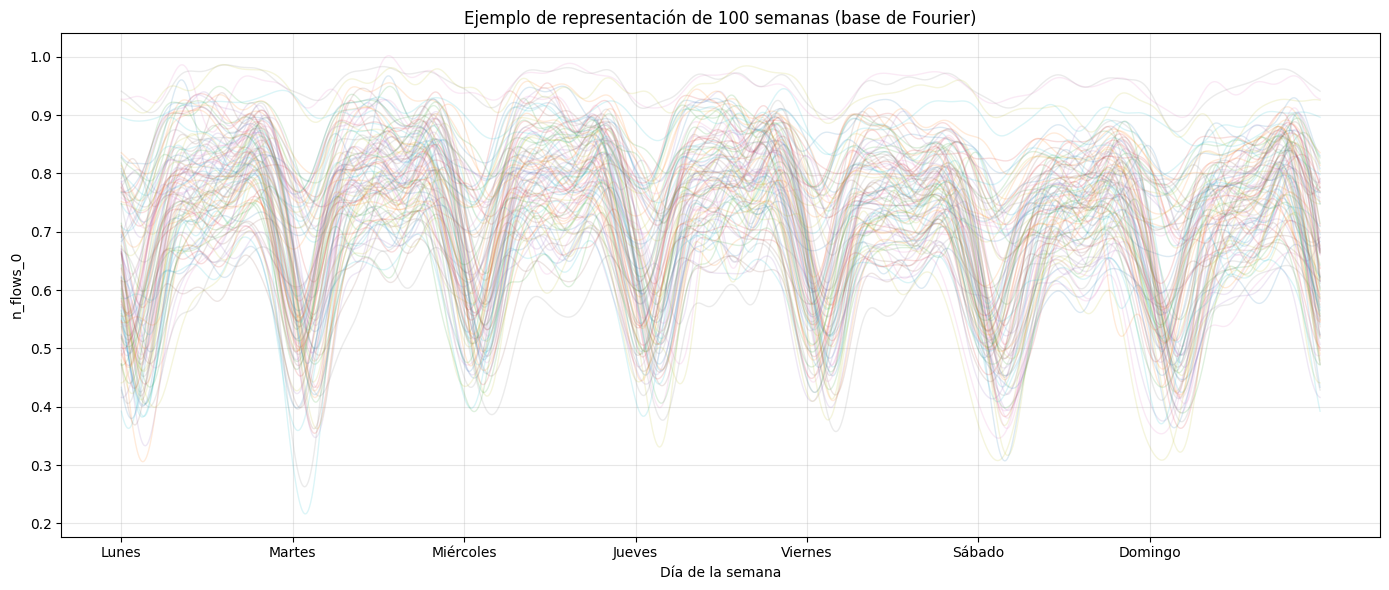

In [14]:
# PASAR DE DATOS ESCALARES A DATOS FUNCIONALES + REPRESENTACION
# ==========================================================
# 1️⃣ LIMPIEZA ROBUSTA
# ==========================================================

df_weeks_clean = df_weeks.copy()

# Convertir ±inf en NaN
df_weeks_clean = df_weeks_clean.replace([np.inf, -np.inf], np.nan)

# Eliminar columnas completamente vacías
df_weeks_clean = df_weeks_clean.dropna(axis=1, how="all")

# Interpolación temporal (por columnas = semanas)
df_weeks_clean = df_weeks_clean.interpolate(
    axis=0,
    method="linear",
    limit_direction="both"
)

# Relleno de seguridad
df_weeks_clean = df_weeks_clean.ffill().bfill()


# ==========================================================
# 2️⃣ DEFINIR DOMINIO TEMPORAL
# ==========================================================

n_time = df_weeks_clean.shape[0]  # puntos temporales por semana

t = np.linspace(0, 1, n_time)  # dominio normalizado [0,1]

# ==========================================================
# 3️⃣ CREAR OBJETO FUNCIONAL
# ==========================================================

fd = FDataGrid(
    data_matrix=df_weeks_clean.T.values,  # (n_semanas, n_time)
    grid_points=t
)

# ==========================================================
# 4️⃣ PROYECCIÓN A BASE DE FOURIER
# ==========================================================

n_basis = 60  # puedes ajustar

basis = FourierBasis(
    domain_range=(0, 1),
    n_basis=n_basis
)

fd_fourier = fd.to_basis(basis)

# ==========================================================
# 5️⃣ EVALUAR FUNCIONES EN LA REJILLA
# ==========================================================

X = fd_fourier(t)  # evaluación
X = X.reshape(X.shape[0], -1)  # aseguramos shape (n_semanas, n_time)

# Convertir a DataFrame con índice correcto
X = pd.DataFrame(
    X,
    index=df_weeks_clean.columns,   # nombres de semanas
    columns=[f"t_{i}" for i in range(X.shape[1])]
)
# ==========================================================
# 6️⃣ REPRESENTACIÓN DE FUNCIONES (≥ 100)
# ==========================================================

# Número de funciones a representar
n_plot = min(100, X.shape[0])

# Eje temporal en horas (10 minutos por punto)
minutes_per_step = 10
x_hours = np.arange(n_time) * minutes_per_step / 60  # 0 → 168 horas

# Ticks diarios
days = ["Lunes", "Martes", "Miércoles", "Jueves",
        "Viernes", "Sábado", "Domingo"]
ticks = np.arange(0, 7 * 24, 24)

plt.figure(figsize=(14, 6))

for idx in X.index[:n_plot]:
    plt.plot(
        x_hours,
        X.loc[idx],
        alpha=0.15,
        linewidth=1
    )

plt.title(f"Ejemplo de representación de {n_plot} semanas (base de Fourier)")
plt.xlabel("Día de la semana")
plt.ylabel(df_TS24_companded.columns[1])
plt.xticks(ticks, days)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [15]:
# DATAFRAME CON LOS COEF. DE LA BASE DE FOURIER
n_coef = fd_fourier.coefficients.shape[1]

coef_df = pd.DataFrame(
    fd_fourier.coefficients,
    index=df_weeks_clean.columns,
    columns=[f"coef_{i}" for i in range(n_coef)]
)

coef_df

,coef_0,coef_1,coef_2,coef_3,coef_4,coef_5,coef_6,coef_7,coef_8,coef_9,...,coef_51,coef_52,coef_53,coef_54,coef_55,coef_56,coef_57,coef_58,coef_59,coef_60
n_flows_0_49_2023,0.869791,0.006517,-0.009471,-0.000122,0.001895,-0.006819,0.009753,0.004482,0.000480,-0.000301,...,-0.001385,-0.003785,-1.418340e-03,0.000393,0.003155,-0.002520,-0.000569,-0.001636,0.001125,-0.002786
n_flows_0_50_2023,0.867441,0.028683,-0.007745,0.004950,0.001117,0.006711,0.003232,0.001192,0.003888,0.003629,...,0.002435,-0.000288,6.120372e-04,0.002389,0.004451,-0.001825,0.000315,0.000697,-0.000571,-0.001206
n_flows_0_51_2023,0.843475,0.036277,-0.007580,0.012610,0.007571,0.003111,0.000026,0.003374,0.003911,0.008025,...,-0.003508,-0.003006,9.008120e-04,0.004118,0.004467,-0.001408,-0.001543,-0.001966,0.000761,0.001619
n_flows_0_52_2023,0.787971,-0.002642,0.002631,0.000213,-0.004000,0.002868,-0.000199,0.001535,0.002356,-0.001754,...,0.000832,-0.001293,-1.780494e-03,0.001404,-0.000031,0.000795,-0.000988,-0.001410,0.000377,-0.001343
n_flows_0_01_2024,0.803369,0.012952,-0.009554,0.003803,0.001840,-0.000462,0.001713,0.001624,-0.002129,-0.002874,...,0.000061,-0.001779,1.573987e-04,0.000784,0.004040,-0.004356,-0.001545,-0.002607,0.001466,-0.000664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
avg_ttl_0_24_2024,0.906918,-0.002994,-0.000880,-0.000360,0.001982,0.000244,-0.001044,-0.001291,-0.000066,-0.000585,...,0.000119,-0.000008,4.312969e-04,-0.000058,0.000178,-0.000160,0.000104,0.000065,0.000217,-0.000347
avg_ttl_0_25_2024,0.911107,-0.001563,-0.005211,-0.000673,0.001665,-0.001177,-0.001842,-0.001803,-0.000151,0.000467,...,0.000116,0.000057,-8.389266e-05,0.000394,0.000450,0.000062,-0.000310,0.000063,0.000215,-0.000299
avg_ttl_0_26_2024,0.912912,-0.009815,-0.004763,0.001680,-0.000588,0.001582,0.003387,-0.004801,0.000085,0.001378,...,0.000241,-0.000085,5.420280e-05,0.000272,0.000133,-0.000395,-0.000059,0.000053,0.000223,-0.000675
avg_ttl_0_27_2024,0.915422,-0.008394,0.001725,-0.004742,0.004791,-0.005092,-0.000717,-0.003206,-0.000168,-0.001040,...,0.000127,0.000207,-8.134355e-07,0.000399,0.000088,-0.000281,-0.000327,-0.000271,-0.000173,-0.000247


In [16]:
# DATAFRAMES DE CADA VARIABLE
prefixes = [
    'n_flows', 'n_packets', 'n_bytes',
    'sum_n_dest_asn', 'average_n_dest_asn', 'std_n_dest_asn',
    'sum_n_dest_ports', 'average_n_dest_ports', 'std_n_dest_ports',
    'sum_n_dest_ip', 'average_n_dest_ip', 'std_n_dest_ip',
    'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes',
    'dir_ratio_packets', 'dir_ratio_bytes',
    'avg_duration', 'avg_ttl'
]

coef_df['prefix'] = coef_df.index.to_series().apply(
    lambda x: next((p for p in prefixes if x.startswith(p)), None)
)

for p, df in coef_df.groupby('prefix'):
    if p is not None:
        globals()[f"df_{p}"] = df.drop(columns='prefix')

df_dir_ratio_packets

,coef_0,coef_1,coef_2,coef_3,coef_4,coef_5,coef_6,coef_7,coef_8,coef_9,...,coef_51,coef_52,coef_53,coef_54,coef_55,coef_56,coef_57,coef_58,coef_59,coef_60
dir_ratio_packets_0_49_2023,0.922280,0.000261,0.001781,0.000630,0.005132,-0.006730,0.002023,0.003627,-0.001507,0.001544,...,0.000091,0.001470,-3.646301e-04,-0.000306,0.000352,0.000135,-0.000196,0.000057,0.000009,0.000003
dir_ratio_packets_0_50_2023,0.926604,-0.001127,-0.005367,-0.003130,0.000503,-0.001743,0.002174,0.000863,0.001023,0.002197,...,0.000053,0.000127,2.428801e-04,-0.000341,-0.000053,-0.000298,-0.000267,-0.000653,-0.000325,0.000139
dir_ratio_packets_0_51_2023,0.929155,0.002836,0.001274,-0.002340,0.001184,-0.000651,-0.000628,-0.000233,-0.001986,0.000606,...,0.000500,0.000662,-1.573766e-04,-0.000146,-0.000380,0.000083,0.000011,-0.000170,0.000145,-0.000500
dir_ratio_packets_0_52_2023,0.931338,-0.004233,-0.001098,-0.000760,0.000565,-0.002552,-0.000364,0.000067,-0.000482,-0.000701,...,-0.000051,0.000099,1.113588e-04,-0.000172,-0.000058,-0.000221,0.000032,-0.000073,-0.000166,0.000166
dir_ratio_packets_0_01_2024,0.925752,0.000012,0.002205,-0.000753,0.002764,-0.001499,0.001738,-0.001460,0.000487,0.001000,...,-0.000158,0.000303,2.735157e-05,-0.000371,0.000244,0.000328,0.000302,0.000262,-0.000166,-0.000080
dir_ratio_packets_0_02_2024,0.918271,0.006429,0.005131,0.005619,0.001906,0.002750,-0.002461,-0.000999,-0.002559,-0.001912,...,-0.000387,0.000334,2.531534e-04,-0.000088,0.000008,0.000018,-0.000202,-0.000253,-0.000391,0.000090
dir_ratio_packets_0_03_2024,0.921924,0.008193,-0.007332,0.001028,0.003128,0.000199,-0.001022,0.002151,0.000757,0.000994,...,0.000372,0.000529,-4.158942e-04,0.000502,-0.000064,-0.000684,0.000632,-0.000656,0.000037,0.000356
dir_ratio_packets_0_04_2024,0.927261,0.004391,0.004852,-0.001913,-0.001545,-0.001507,-0.000988,0.000072,0.000047,-0.002816,...,0.000161,0.000566,3.232987e-04,0.000221,0.000091,-0.000180,-0.000052,-0.000009,-0.000521,-0.000624
dir_ratio_packets_0_05_2024,0.939032,-0.009151,-0.002192,-0.000911,0.001222,-0.001606,-0.000527,-0.000893,0.002206,0.000914,...,-0.001035,0.000115,-1.150020e-03,0.000047,0.000390,-0.000287,-0.000428,-0.000230,-0.000584,-0.000600
dir_ratio_packets_0_06_2024,0.944470,-0.000396,-0.000895,0.000110,-0.002301,0.001064,-0.001169,0.000607,-0.002559,0.000392,...,0.000156,-0.000022,8.653086e-05,-0.000052,0.000751,-0.000159,0.000573,-0.000143,0.000069,0.000494


In [17]:
# =========================================
# CONFIG
# =========================================

TRAIN_END = (2024, 19)
TEST_WEEK = (2024, 20)
TARGET_INST = 0

WINDOW_SIZE = 12
EPOCHS = 400
patience = 40

# =========================================
# IMPORTS
# =========================================

import numpy as np
import pandas as pd
import re
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# =========================================
# PARSE INDEX
# =========================================

def parse_index(idx):
    match = re.match(r"n_packets_(\d+)_(\d+)_(\d+)", idx)
    inst, week, year = match.groups()
    return int(inst), int(year), int(week)

df = df_n_packets.copy()

df[['inst','year','week']] = df.index.to_series().apply(
    lambda x: pd.Series(parse_index(x))
)

df = df.sort_values(['inst','year','week'])

coef_cols = df_n_packets.columns

# =========================================
# SPLIT
# =========================================

def split_data(df, train_end, test_week):
    y_end, w_end = train_end
    y_test, w_test = test_week
    
    train = df[
        (df['year'] < y_end) |
        ((df['year'] == y_end) & (df['week'] <= w_end))
    ]
    
    test = df[
        (df['year'] == y_test) &
        (df['week'] == w_test)
    ]
    
    return train, test

train_df, test_df = split_data(df, TRAIN_END, TEST_WEEK)

# =========================================
# SECUENCIAS
# =========================================

scalers = {}

def create_sequences(df):
    X, y, inst_ids = [], [], []
    
    inst_list = sorted(df['inst'].unique())
    inst_to_idx = {inst:i for i,inst in enumerate(inst_list)}
    
    for inst in inst_list:
        df_inst = df[df['inst'] == inst].sort_values(['year','week'])
        values = df_inst[coef_cols].values
        
        values_no_dc = values[:, 1:]
        deltas = np.diff(values_no_dc, axis=0)
        
        scaler = StandardScaler()
        deltas_scaled = scaler.fit_transform(deltas)
        
        scalers[inst] = scaler
        
        for i in range(len(deltas_scaled) - WINDOW_SIZE):
            X.append(deltas_scaled[i:i+WINDOW_SIZE])
            y.append(deltas_scaled[i+WINDOW_SIZE])
            inst_ids.append(inst_to_idx[inst])
    
    return np.array(X), np.array(y), np.array(inst_ids), inst_to_idx

X, y, inst_ids, inst_to_idx = create_sequences(train_df)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
inst_ids = torch.tensor(inst_ids, dtype=torch.long)

X_train, X_val, y_train, y_val, inst_train, inst_val = train_test_split(
    X, y, inst_ids, test_size=0.2, random_state=42
)

# =========================================
# HYPERPARAM SEARCH
# =========================================

search_space = {
    'hidden_size': [64, 128, 256],
    'num_layers': [1, 2],
    'dropout': [0.0, 0.2],
    'lr': [1e-3, 5e-4],
    'embedding_dim': [8, 16]
}

def train_eval_model(params):
    
    class Model(nn.Module):
        def __init__(self):
            super().__init__()
            self.embedding = nn.Embedding(len(inst_to_idx), params['embedding_dim'])
            self.lstm = nn.LSTM(
                X.shape[2] + params['embedding_dim'],
                params['hidden_size'],
                num_layers=params['num_layers'],
                dropout=params['dropout'],
                batch_first=True
            )
            self.fc = nn.Linear(params['hidden_size'], X.shape[2])

        def forward(self, x, inst_id):
            emb = self.embedding(inst_id)
            emb = emb.unsqueeze(1).repeat(1, x.size(1), 1)
            x = torch.cat([x, emb], dim=2)
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :])

    model = Model()
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    criterion = nn.SmoothL1Loss()
    
    best_val = float('inf')
    counter = 0
    
    for epoch in range(150):
        
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train, inst_train), y_train)
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val, inst_val), y_val)
        
        if val_loss < best_val:
            best_val = val_loss
            counter = 0
        else:
            counter += 1
        
        if counter > 20:
            break
    
    return best_val.item()

# ejecutar búsqueda
results = []

# for i in range(10):
#     params = {k: random.choice(v) for k,v in search_space.items()}
#     print(f"Trial {i+1}: {params}")
    
#     val_loss = train_eval_model(params)
#     print("Val:", val_loss)
    
#     results.append((val_loss, params))

# results.sort(key=lambda x: x[0])
# best_params = results[0][1]

best_params = {'hidden_size': 256, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.0005, 'embedding_dim': 8}
print("\nBEST PARAMS:", best_params)

# =========================================
# MODELO FINAL
# =========================================

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.embedding = nn.Embedding(len(inst_to_idx), best_params['embedding_dim'])
        
        self.lstm = nn.LSTM(
            X.shape[2] + best_params['embedding_dim'],
            best_params['hidden_size'],
            num_layers=best_params['num_layers'],
            dropout=best_params['dropout'],
            batch_first=True
        )
        
        self.fc = nn.Linear(best_params['hidden_size'], X.shape[2])

    def forward(self, x, inst_id):
        emb = self.embedding(inst_id)
        emb = emb.unsqueeze(1).repeat(1, x.size(1), 1)
        x = torch.cat([x, emb], dim=2)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = LSTMModel()
optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'])
criterion = nn.SmoothL1Loss()

# =========================================
# TRAIN FINAL
# =========================================

best_loss = float('inf')
counter = 0

for epoch in range(EPOCHS):
    
    model.train()
    optimizer.zero_grad()
    
    loss = criterion(model(X_train, inst_train), y_train)
    loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val, inst_val), y_val)
    
    if epoch % 20 == 0:
        print(f"{epoch} | train {loss.item():.4f} | val {val_loss.item():.4f}")
    
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
    else:
        counter += 1
    
    if counter > patience:
        print("Early stopping")
        break

# =========================================
# PREDICCIÓN
# =========================================

inst_idx = inst_to_idx[TARGET_INST]

df_inst = train_df[train_df['inst'] == TARGET_INST].sort_values(['year','week'])
values = df_inst[coef_cols].values

baseline = values[:, 0]
shape = values[:, 1:]

deltas = np.diff(shape, axis=0)
scaler = scalers[TARGET_INST]

deltas_scaled = scaler.transform(deltas)

last_window = torch.tensor(deltas_scaled[-WINDOW_SIZE:], dtype=torch.float32).unsqueeze(0)
inst_tensor = torch.tensor([inst_idx])

with torch.no_grad():
    pred_delta = scaler.inverse_transform(
        model(last_window, inst_tensor).numpy()
    )[0]

pred_shape = shape[-1] + pred_delta
pred_coef = np.concatenate([[baseline[-1]], pred_shape])

real = test_df[test_df['inst'] == TARGET_INST][coef_cols].values[0]

# =========================================
# RECONSTRUCCIÓN
# =========================================

def reconstruct_signal_week(coefs, n_points):
    t = np.linspace(0, 2*np.pi, n_points)
    result = np.ones_like(t) * coefs[0]
    k = 1
    idx = 1
    while idx < len(coefs)-1:
        result += coefs[idx]*np.cos(k*t) + coefs[idx+1]*np.sin(k*t)
        idx += 2
        k += 1
    return result

n_time = int(7 * 24 * 60 / 10)
x_hours = np.arange(n_time) / 6

signal_real = reconstruct_signal_week(real, n_time)
signal_pred = reconstruct_signal_week(pred_coef, n_time)

# =========================================
# MÉTRICAS
# =========================================

mae = np.mean(np.abs(signal_real - signal_pred))
rmse = np.sqrt(np.mean((signal_real - signal_pred)**2))

print("\n===== MÉTRICAS =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")



BEST PARAMS: {'hidden_size': 256, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.0005, 'embedding_dim': 8}
0 | train 0.4113 | val 0.3715
20 | train 0.2674 | val 0.4964
40 | train 0.0444 | val 0.6759
Early stopping

===== MÉTRICAS =====
MAE  : 0.0224
RMSE : 0.0293


In [18]:
# PREDICCION POR VARIABLE EN UNA SEMANA E INSTITUCION
# =========================================
# CONFIG
# =========================================

TRAIN_END = (2024, 19)
TEST_WEEK = (2024, 20)
TARGET_INST = 0

WINDOW_SIZE = 12
EPOCHS = 400
patience = 40

# =========================================
# IMPORTS
# =========================================

import numpy as np
import pandas as pd
import re
import torch
import torch.nn as nn
import random

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# =========================================
# DATASETS POR PREFIX
# =========================================

df_dict = {}

prefixes = [
    'n_flows', 'n_packets', 'n_bytes',
    'sum_n_dest_asn', 'average_n_dest_asn', 'std_n_dest_asn',
    'sum_n_dest_ports', 'average_n_dest_ports', 'std_n_dest_ports',
    'sum_n_dest_ip', 'average_n_dest_ip', 'std_n_dest_ip',
    'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes',
    'dir_ratio_packets', 'dir_ratio_bytes',
    'avg_duration', 'avg_ttl'
]

coef_df['prefix'] = coef_df.index.to_series().apply(
    lambda x: next((p for p in prefixes if x.startswith(p)), None)
)

for p, df in coef_df.groupby('prefix'):
    if p is not None:
        df_dict[p] = df.drop(columns='prefix')

# =========================================
# SPLIT
# =========================================

def split_data(df, train_end, test_week):
    y_end, w_end = train_end
    y_test, w_test = test_week

    train = df[
        (df['year'] < y_end) |
        ((df['year'] == y_end) & (df['week'] <= w_end))
    ]

    test = df[
        (df['year'] == y_test) &
        (df['week'] == w_test)
    ]

    return train, test

# =========================================
# PIPELINE
# =========================================

def run_pipeline(df, prefix_name):

    print(f"\n========== RUNNING: {prefix_name} ==========")

    def parse_index(idx):
        match = re.match(rf"{prefix_name}_(\d+)_(\d+)_(\d+)", idx)
        inst, week, year = match.groups()
        return int(inst), int(year), int(week)

    df = df.copy()
    df[['inst','year','week']] = df.index.to_series().apply(
        lambda x: pd.Series(parse_index(x))
    )

    df = df.sort_values(['inst','year','week'])

    coef_cols = df.columns.drop(['inst','year','week'])

    train_df, test_df = split_data(df, TRAIN_END, TEST_WEEK)

    scalers = {}

    def create_sequences(df):
        X, y, inst_ids = [], [], []

        inst_list = sorted(df['inst'].unique())
        inst_to_idx = {inst:i for i,inst in enumerate(inst_list)}

        for inst in inst_list:
            df_inst = df[df['inst'] == inst].sort_values(['year','week'])
            values = df_inst[coef_cols].values

            values_no_dc = values[:, 1:]
            deltas = np.diff(values_no_dc, axis=0)

            scaler = StandardScaler()
            deltas_scaled = scaler.fit_transform(deltas)

            scalers[inst] = scaler

            for i in range(len(deltas_scaled) - WINDOW_SIZE):
                X.append(deltas_scaled[i:i+WINDOW_SIZE])
                y.append(deltas_scaled[i+WINDOW_SIZE])
                inst_ids.append(inst_to_idx[inst])

        return (
            torch.tensor(np.array(X), dtype=torch.float32),
            torch.tensor(np.array(y), dtype=torch.float32),
            torch.tensor(np.array(inst_ids), dtype=torch.long),
            inst_to_idx
        )

    X, y, inst_ids, inst_to_idx = create_sequences(train_df)

    X_train, X_val, y_train, y_val, inst_train, inst_val = train_test_split(
        X, y, inst_ids, test_size=0.2, random_state=42
    )

    input_dim = X.shape[2]

    best_params = {
        'hidden_size': 256,
        'num_layers': 1,
        'dropout': 0.0,
        'lr': 5e-4,
        'embedding_dim': 8
    }

    class LSTMModel(nn.Module):
        def __init__(self):
            super().__init__()

            self.embedding = nn.Embedding(len(inst_to_idx), best_params['embedding_dim'])

            self.lstm = nn.LSTM(
                input_dim + best_params['embedding_dim'],
                best_params['hidden_size'],
                num_layers=best_params['num_layers'],
                dropout=best_params['dropout'],
                batch_first=True
            )

            self.fc = nn.Linear(best_params['hidden_size'], input_dim)

        def forward(self, x, inst_id):
            emb = self.embedding(inst_id)
            emb = emb.unsqueeze(1).repeat(1, x.size(1), 1)
            x = torch.cat([x, emb], dim=2)
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :])

    model = LSTMModel()
    optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'])
    criterion = nn.SmoothL1Loss()

    # =========================================
    # TRAIN
    # =========================================

    best_loss = float('inf')
    counter = 0

    for epoch in range(EPOCHS):

        model.train()
        optimizer.zero_grad()

        loss = criterion(model(X_train, inst_train), y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val, inst_val), y_val)

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
        else:
            counter += 1

        if counter > patience:
            break

    # =========================================
    # PREDICCIÓN (INSTANCIA OBJETIVO)
    # =========================================

    inst_idx = inst_to_idx[TARGET_INST]

    df_inst = train_df[train_df['inst'] == TARGET_INST].sort_values(['year','week'])
    values = df_inst[coef_cols].values

    baseline = values[:, 0]
    shape = values[:, 1:]

    deltas = np.diff(shape, axis=0)
    scaler = scalers[TARGET_INST]
    deltas_scaled = scaler.transform(deltas)

    last_window = torch.tensor(deltas_scaled[-WINDOW_SIZE:], dtype=torch.float32).unsqueeze(0)
    inst_tensor = torch.tensor([inst_idx])

    with torch.no_grad():
        pred_delta = scaler.inverse_transform(
            model(last_window, inst_tensor).numpy()
        )[0]

    pred_shape = shape[-1] + pred_delta
    pred_coef = np.concatenate([[baseline[-1]], pred_shape])

    real = test_df[test_df['inst'] == TARGET_INST][coef_cols].values[0]

    # =========================================
    # RECONSTRUCCIÓN SEÑAL
    # =========================================

    def reconstruct_signal_week(coefs, n_points):
        t = np.linspace(0, 2*np.pi, n_points)
        result = np.ones_like(t) * coefs[0]
        k = 1
        idx = 1
        while idx < len(coefs)-1:
            result += coefs[idx]*np.cos(k*t) + coefs[idx+1]*np.sin(k*t)
            idx += 2
            k += 1
        return result

    n_time = int(7 * 24 * 60 / 10)

    signal_real = reconstruct_signal_week(real, n_time)
    signal_pred = reconstruct_signal_week(pred_coef, n_time)

    # =========================================
    # MÉTRICAS
    # =========================================

    mae = np.mean(np.abs(signal_real - signal_pred))
    rmse = np.sqrt(np.mean((signal_real - signal_pred)**2))

    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return {
        "model": model,
        "scalers": scalers,
        "inst_to_idx": inst_to_idx,
        "test_df": test_df,
        "mae": mae,
        "rmse": rmse
    }

# =========================================
# EJECUTAR TODOS LOS PREFIJOS
# =========================================

results_all = {}
metrics_summary = []

for prefix, df in df_dict.items():

    result = run_pipeline(df, prefix)

    results_all[prefix] = result

    metrics_summary.append({
        "prefix": prefix,
        "MAE": result["mae"],
        "RMSE": result["rmse"]
    })

# =========================================
# RESUMEN FINAL
# =========================================

metrics_df = pd.DataFrame(metrics_summary)
print("\n===== SUMMARY =====")
print(metrics_df.sort_values("RMSE"))


========== RUNNING: average_n_dest_asn ==========
MAE : 0.0049
RMSE: 0.0065

========== RUNNING: average_n_dest_ip ==========
MAE : 0.0083
RMSE: 0.0116

========== RUNNING: average_n_dest_ports ==========
MAE : 0.0192
RMSE: 0.0257

========== RUNNING: avg_duration ==========
MAE : 0.0049
RMSE: 0.0066

========== RUNNING: avg_ttl ==========
MAE : 0.0036
RMSE: 0.0046

========== RUNNING: dir_ratio_bytes ==========
MAE : 0.0023
RMSE: 0.0028

========== RUNNING: dir_ratio_packets ==========
MAE : 0.0022
RMSE: 0.0028

========== RUNNING: n_bytes ==========
MAE : 0.0239
RMSE: 0.0315

========== RUNNING: n_flows ==========
MAE : 0.0197
RMSE: 0.0247

========== RUNNING: n_packets ==========
MAE : 0.0227
RMSE: 0.0296

========== RUNNING: std_n_dest_asn ==========
MAE : 0.0129
RMSE: 0.0158

========== RUNNING: std_n_dest_ip ==========
MAE : 0.0121
RMSE: 0.0166

========== RUNNING: std_n_dest_ports ==========
MAE : 0.0756
RMSE: 0.0963

========== RUNNING: sum_n_dest_asn ==========
MAE : 0.0101
R

In [20]:
# =========================================
# RESUMEN FINAL
# =========================================

metrics_df = pd.DataFrame(metrics_summary)

# Media global
mean_mae = metrics_df["MAE"].mean()
mean_rmse = metrics_df["RMSE"].mean()

# Añadir como última fila
metrics_df.loc[len(metrics_df)] = {
    "prefix": "MEDIA",
    "MAE": mean_mae,
    "RMSE": mean_rmse
}

print("\n===== SUMMARY =====")
print(metrics_df.sort_values("RMSE"))

print("\n===== GLOBAL MEAN =====")
print(f"MAE medio : {mean_mae:.4f}")
print(f"RMSE medio: {mean_rmse:.4f}")


===== SUMMARY =====
                   prefix       MAE      RMSE
6       dir_ratio_packets  0.002161  0.002766
5         dir_ratio_bytes  0.002276  0.002812
16    tcp_udp_ratio_bytes  0.003151  0.003651
17  tcp_udp_ratio_packets  0.003468  0.004029
4                 avg_ttl  0.003570  0.004603
0      average_n_dest_asn  0.004883  0.006540
3            avg_duration  0.004875  0.006568
1       average_n_dest_ip  0.008330  0.011630
13         sum_n_dest_asn  0.010124  0.012221
10         std_n_dest_asn  0.012885  0.015762
14          sum_n_dest_ip  0.012718  0.016448
11          std_n_dest_ip  0.012077  0.016603
18                  MEDIA  0.014641  0.018808
8                 n_flows  0.019712  0.024719
2    average_n_dest_ports  0.019176  0.025662
15       sum_n_dest_ports  0.021868  0.027228
9               n_packets  0.022668  0.029580
7                 n_bytes  0.023947  0.031473
12       std_n_dest_ports  0.075647  0.096256

===== GLOBAL MEAN =====
MAE medio : 0.0146
RMSE medio: 0.0

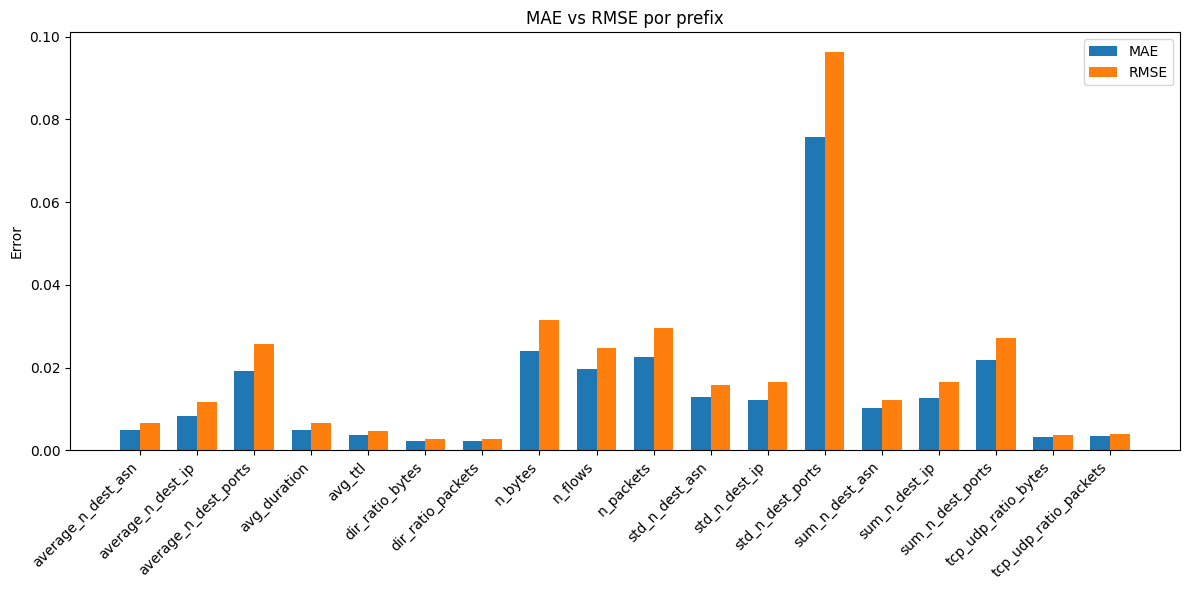

In [19]:
# HISTOGRAMA DE ERRORES
plt.figure(figsize=(12, 6))  # <-- más ancho

x = range(len(metrics_df))
width = 0.35

plt.bar([i - width/2 for i in x], metrics_df["MAE"], width=width, label="MAE")
plt.bar([i + width/2 for i in x], metrics_df["RMSE"], width=width, label="RMSE")

plt.xticks(x, metrics_df["prefix"], rotation=45, ha="right")  # <-- mejor alineación
plt.ylabel("Error")
plt.title("MAE vs RMSE por prefix")
plt.legend()

plt.tight_layout()

# Guardar en PDF
plt.savefig(
    "errores_LSTM_10MIN.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()